In [23]:
"""
DC Gradient Axial Confinement Scan
=====================================
Produces:
  - Figure 3.7: Ion count rate vs. injection energy, for three DC gradient
    configurations (negative-slope, no-gradient, positive-slope)

Characterizes axial ion confinement along the PCB RFQ under a 10 V DC
difference across the 20-resistor gradient chain, at Vpp = 320 V, 1144 kHz,
4.389e-3 mbar (gauge 6.9e-6, baseline 2.0e-6), 1.79 W heating power.
"""

import re
import glob
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [24]:
def read_mpa_file(filepath):
    """Parses REALTIME and TOTALSUM from an MPANT ASCII export."""
    realtime = None
    totalsum = None
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("REALTIME") and realtime is None:
                realtime = float(line.split()[1].strip())
            elif line.startswith("TOTALSUM") and totalsum is None:
                totalsum = float(line.split()[1].strip())
    return realtime, totalsum


def get_rate_and_uncertainty(filepath):
    realtime, totalsum = read_mpa_file(filepath)
    if realtime is None or totalsum is None:
        print(f"WARNING: couldn't parse REALTIME/TOTALSUM from {filepath}, skipping")
        return None, None
    rate = totalsum / realtime
    rate_unc = np.sqrt(totalsum) / realtime
    return rate, rate_unc


def parse_grad_filename(filepath):
    """Extract DC gradient label, injection energy (relative to DC In, can be
    negative), and run number from filenames like Grad_6_2.mpa (run 1),
    Grad_10_-5.mpa (injection=-5V), Grad_-6_11.5_2.mpa (run 2).

    Note the inverted sign convention: filename '6' = negative gradient,
    filename '-6' = positive gradient, '0' = no gradient.
    """
    basename = filepath.split("/")[-1]
    match = re.match(r"Grad_(-?\d+)_(-?\d+(?:\.\d+)?)(?:_(\d+))?\.mpa$", basename)
    if match is None:
        return None
    grad_label = int(match.group(1))
    injection_v = float(match.group(2))
    run = int(match.group(3)) if match.group(3) else 1
    return grad_label, injection_v, run


def grad_type_from_label(grad_label):
    if grad_label == 0:
        return "No Gradient"
    elif grad_label > 0:
        return "Negative Gradient"
    else:
        return "Positive Gradient"


grad_files = [f for f in glob.glob("Gradient/Grad_*.mpa") if "Noise" not in f]

grad_runs = []
for filepath in grad_files:
    parsed = parse_grad_filename(filepath)
    if parsed is None:
        continue
    grad_label, injection_v, run = parsed
    grad_runs.append({
        "filepath": filepath,
        "grad_label": grad_label,
        "grad_type": grad_type_from_label(grad_label),
        "injection_v": injection_v,
        "run": run,
    })

grad_runs_df = pd.DataFrame(grad_runs).sort_values(["run", "grad_label", "injection_v"]).reset_index(drop=True)

grad_runs_df["rate_hz"], grad_runs_df["rate_unc_hz"] = zip(
    *grad_runs_df["filepath"].apply(get_rate_and_uncertainty)
)

grad_runs_df

,filepath,grad_label,grad_type,injection_v,run,rate_hz,rate_unc_hz
0,Gradient/Grad_-10_5.mpa,-10,Positive Gradient,5.0,1,3.886049,0.196778
1,Gradient/Grad_-10_6.mpa,-10,Positive Gradient,6.0,1,3.396753,0.183944
2,Gradient/Grad_-10_7.mpa,-10,Positive Gradient,7.0,1,3.307135,0.181503
3,Gradient/Grad_-10_8.mpa,-10,Positive Gradient,8.0,1,3.506675,0.186906
4,Gradient/Grad_-10_9.mpa,-10,Positive Gradient,9.0,1,3.746475,0.193210
...,...,...,...,...,...,...,...
110,Gradient/Grad_10_8_2.mpa,10,Negative Gradient,8.0,2,552.266688,2.348838
111,Gradient/Grad_10_9_2.mpa,10,Negative Gradient,9.0,2,581.485438,2.409486
112,Gradient/Grad_10_10_2.mpa,10,Negative Gradient,10.0,2,646.543622,2.542493
113,Gradient/Grad_10_11_2.mpa,10,Negative Gradient,11.0,2,679.352703,2.602616


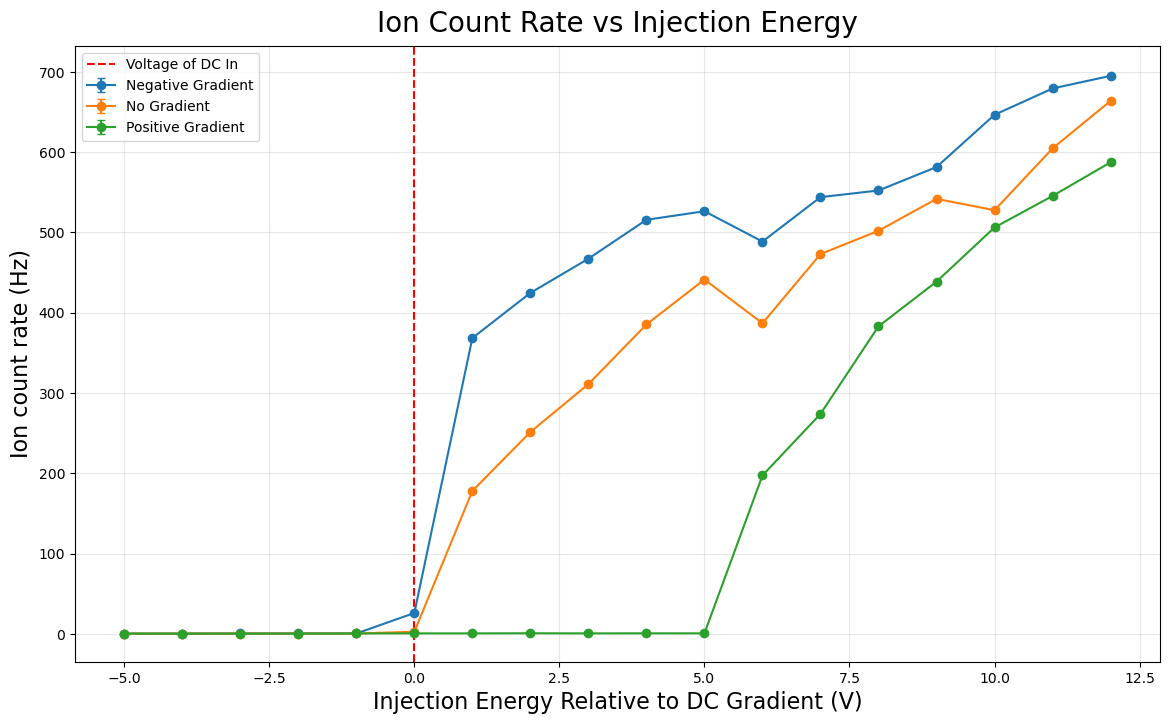

In [25]:
"""
Figure 3.7: Ion Count Rate vs. Injection Energy, by DC Gradient Configuration
------------------------------------------------------------------------------
Correct/final dataset (previously labeled "Run 2" — an earlier attempt under
different conditions was superseded and is not included here).
"""

gradient_scan = grad_runs_df[grad_runs_df["run"] == 2].copy()

plt.figure(figsize=(14, 8))

for grad_type, group in gradient_scan.groupby("grad_type"):
    group = group.sort_values("injection_v")
    plt.errorbar(
        group["injection_v"], group["rate_hz"], yerr=group["rate_unc_hz"],
        marker="o", capsize=3, label=grad_type
    )

plt.axvline(x=0, color='r', linestyle='--', label='Voltage of DC In')
plt.xlabel("Injection Energy Relative to DC Gradient (V)", fontsize=16)
plt.ylabel("Ion count rate (Hz)", fontsize=16)
plt.title("Ion Count Rate vs Injection Energy", fontsize=20, pad=10)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
def export_figure_csv(dataframe, filepath, description_lines):
    """Writes a CSV with a commented header block describing the table's
    purpose and thesis figure reference, followed by the actual data."""
    with open(filepath, "w") as f:
        for line in description_lines:
            f.write(f"# {line}\n")
    dataframe.to_csv(filepath, mode="a", index=False)


def archive_raw_files(filenames, source_folder, dest_subfolder):
    """Copies the raw .mpa files underlying a given figure/table into their
    own subfolder under thesis/raw/, preserving full provenance."""
    dest_path = os.path.join("thesis", "raw", dest_subfolder)
    os.makedirs(dest_path, exist_ok=True)

    copied, missing = [], []
    for fname in filenames:
        src = os.path.join(source_folder, fname)
        dst = os.path.join(dest_path, fname)
        if os.path.exists(src):
            shutil.copy2(src, dst)
            copied.append(fname)
        else:
            missing.append(fname)

    print(f"Copied {len(copied)} files to {dest_path}")
    if missing:
        print(f"WARNING: {len(missing)} files not found: {missing}")
    return copied, missing


os.makedirs("thesis", exist_ok=True)

description = [
    "Ion Count Rate vs. Injection Energy, by DC Gradient Configuration",
    "Corresponds to Figure 3.7",
    "",
    "Purpose: characterizes axial ion confinement/transport along the PCB RFQ",
    "under three DC gradient configurations (10V difference across the",
    "20-resistor chain): a negative-slope gradient (accelerating ions toward",
    "the exit), a flat no-gradient configuration, and a positive-slope",
    "gradient (opposing ion motion). Injection energy is swept and expressed",
    "relative to the DC In voltage, testing how much kinetic energy an ion",
    "needs on entry to be transmitted under each axial field configuration.",
    "",
    "Conditions: Vpp=320V, 1144kHz, pressure=4.389e-3 mbar",
    "(gauge reading 6.9e-6, baseline 2.0e-6), heating power 1.79W.",
    "",
    "Columns:",
    "  grad_type    - DC gradient configuration",
    "  injection_v  - Injection energy relative to DC Gradient (V)",
    "  rate_hz      - Ion count rate (Hz)",
    "  rate_unc_hz  - Ion count rate uncertainty (Hz)",
    "  file         - Source .mpa filename",
]

export_cols = ["grad_type", "injection_v", "rate_hz", "rate_unc_hz", "filepath"]
export_df = gradient_scan[export_cols].rename(columns={"filepath": "file"})
export_df = export_df.sort_values(["grad_type", "injection_v"]).reset_index(drop=True)

export_figure_csv(export_df, "thesis/gradient_scan.csv", description)
print(export_df)

archive_raw_files(gradient_scan["filepath"].str.split("/").str[-1].tolist(), "Gradient", "gradient_scan")

            grad_type  injection_v     rate_hz  rate_unc_hz  \
0   Negative Gradient         -5.0    0.309752     0.055633   
1   Negative Gradient         -4.0    0.349703     0.059111   
2   Negative Gradient         -3.0    0.479674     0.069235   
3   Negative Gradient         -2.0    0.489628     0.069947   
4   Negative Gradient         -1.0    0.449717     0.067040   
5   Negative Gradient          0.0   25.950332     0.508635   
6   Negative Gradient          1.0  368.452607     1.918764   
7   Negative Gradient          2.0  424.668874     2.058035   
8   Negative Gradient          3.0  467.295315     2.159381   
9   Negative Gradient          4.0  515.761455     2.267549   
10  Negative Gradient          5.0  526.434398     2.291142   
11  Negative Gradient          6.0  488.625588     2.208490   
12  Negative Gradient          7.0  543.972248     2.331983   
13  Negative Gradient          8.0  552.266688     2.348838   
14  Negative Gradient          9.0  581.485438     2.40

(['Grad_-10_-5_2.mpa',
  'Grad_-10_-4_2.mpa',
  'Grad_-10_-3_2.mpa',
  'Grad_-10_-2_2.mpa',
  'Grad_-10_-1_2.mpa',
  'Grad_-10_0_2.mpa',
  'Grad_-10_1_2.mpa',
  'Grad_-10_2_2.mpa',
  'Grad_-10_3_2.mpa',
  'Grad_-10_4_2.mpa',
  'Grad_-10_5_2.mpa',
  'Grad_-10_6_2.mpa',
  'Grad_-10_7_2.mpa',
  'Grad_-10_8_2.mpa',
  'Grad_-10_9_2.mpa',
  'Grad_-10_10_2.mpa',
  'Grad_-10_11_2.mpa',
  'Grad_-10_12_2.mpa',
  'Grad_0_-5_2.mpa',
  'Grad_0_-4_2.mpa',
  'Grad_0_-3_2.mpa',
  'Grad_0_-2_2.mpa',
  'Grad_0_-1_2.mpa',
  'Grad_0_0_2.mpa',
  'Grad_0_1_2.mpa',
  'Grad_0_2_2.mpa',
  'Grad_0_3_2.mpa',
  'Grad_0_4_2.mpa',
  'Grad_0_5_2.mpa',
  'Grad_0_6_2.mpa',
  'Grad_0_7_2.mpa',
  'Grad_0_8_2.mpa',
  'Grad_0_9_2.mpa',
  'Grad_0_10_2.mpa',
  'Grad_0_11_2.mpa',
  'Grad_0_12_2.mpa',
  'Grad_10_-5_2.mpa',
  'Grad_10_-4_2.mpa',
  'Grad_10_-3_2.mpa',
  'Grad_10_-2_2.mpa',
  'Grad_10_-1_2.mpa',
  'Grad_10_0_2.mpa',
  'Grad_10_1_2.mpa',
  'Grad_10_2_2.mpa',
  'Grad_10_3_2.mpa',
  'Grad_10_4_2.mpa',
  'Grad_10_5_